In [1]:
import pandas as pd
import numpy as np

print("EduPredict - Student Performance Prediction")
print("Libraries loaded successfully!")

EduPredict - Student Performance Prediction
Libraries loaded successfully!


In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch Student Performance dataset
student_data = fetch_ucirepo(id=320)

# Separate features and target
X = student_data.data.features
y = student_data.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (649, 30)
Target shape: (649, 3)


In [4]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [6]:
y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [8]:
print("Number of features:", X.shape[1])
print("\nAll feature names:\n")

for i, column in enumerate(X.columns, 1):
    print(f"{i}. {column}")

Number of features: 30

All feature names:

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences


In [9]:
print("\nTarget column(s):")
print(y.columns.tolist())


Target column(s):
['G1', 'G2', 'G3']


In [10]:
print("\nTarget information:")
print(y.info())
print("\nTarget statistics:")
print(y.describe())


Target information:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   G1      649 non-null    int64
 1   G2      649 non-null    int64
 2   G3      649 non-null    int64
dtypes: int64(3)
memory usage: 15.3 KB
None

Target statistics:
               G1          G2          G3
count  649.000000  649.000000  649.000000
mean    11.399076   11.570108   11.906009
std      2.745265    2.913639    3.230656
min      0.000000    0.000000    0.000000
25%     10.000000   10.000000   10.000000
50%     11.000000   11.000000   12.000000
75%     13.000000   13.000000   14.000000
max     19.000000   19.000000   19.000000


In [11]:
print("Correlation between grades:")
print(y.corr())

Correlation between grades:
          G1        G2        G3
G1  1.000000  0.864982  0.826387
G2  0.864982  1.000000  0.918548
G3  0.826387  0.918548  1.000000


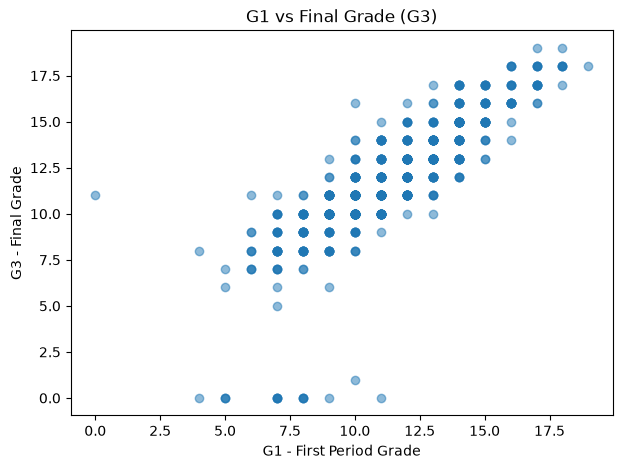

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y["G1"], y["G3"], alpha=0.5)
plt.xlabel("G1 - First Period Grade")
plt.ylabel("G3 - Final Grade")
plt.title("G1 vs Final Grade (G3)")
plt.show()

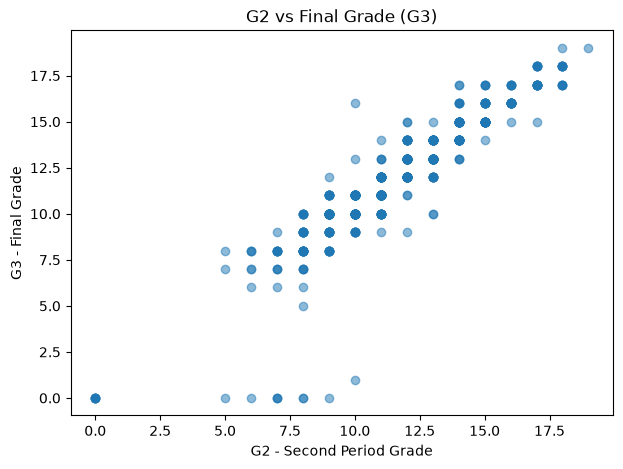

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(y["G2"], y["G3"], alpha=0.5)
plt.xlabel("G2 - Second Period Grade")
plt.ylabel("G3 - Final Grade")
plt.title("G2 vs Final Grade (G3)")
plt.show()

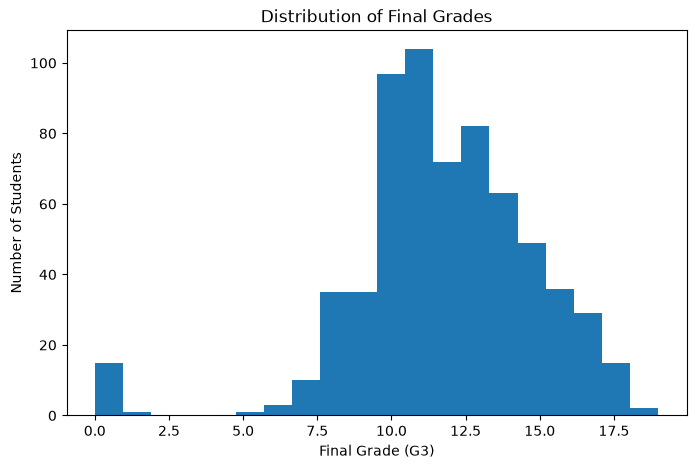

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(y["G3"], bins=20)

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()

In [15]:
print("G3 value counts:")
print(y["G3"].value_counts().sort_index())

G3 value counts:
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


In [16]:
print("Mean G3:", y["G3"].mean())
print("Median G3:", y["G3"].median())
print("Minimum G3:", y["G3"].min())
print("Maximum G3:", y["G3"].max())

Mean G3: 11.906009244992296
Median G3: 12.0
Minimum G3: 0
Maximum G3: 19


In [17]:
# Create binary target for academic risk

target = y["G3"].apply(lambda grade: 1 if grade < 10 else 0)

print("Target created successfully!")
print()
print("Target distribution:")
print(target.value_counts())

Target created successfully!

Target distribution:
G3
0    549
1    100
Name: count, dtype: int64


In [18]:
print("\nTarget percentages:")
print(target.value_counts(normalize=True) * 100)


Target percentages:
G3
0    84.59168
1    15.40832
Name: proportion, dtype: float64


In [19]:
# Features
X_model = X.copy()

# Target
y_model = target

print("Features shape:", X_model.shape)
print("Target shape:", y_model.shape)

Features shape: (649, 30)
Target shape: (649,)


In [21]:
print("Feature columns:")
print(X_model.columns.tolist())

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [22]:
target = y["G3"].apply(lambda grade: 1 if grade < 10 else 0)

print("Target created successfully!")
print()
print("Target distribution:")
print(target.value_counts())

Target created successfully!

Target distribution:
G3
0    549
1    100
Name: count, dtype: int64


In [23]:
print("\nTarget percentages:")
print(target.value_counts(normalize=True) * 100)


Target percentages:
G3
0    84.59168
1    15.40832
Name: proportion, dtype: float64


In [24]:
X_model = X.copy()
y_model = target

print("Features shape:", X_model.shape)
print("Target shape:", y_model.shape)

Features shape: (649, 30)
Target shape: (649,)


In [25]:
print("Feature columns:")
print(X_model.columns.tolist())

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (519, 30)
Testing features: (130, 30)

Training target distribution:
G3
0    439
1     80
Name: count, dtype: int64

Testing target distribution:
G3
0    110
1     20
Name: count, dtype: int64


In [27]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Number of categorical features: 17
Number of numerical features: 13


C:\Users\arjun\AppData\Local\Temp\ipykernel_17552\3735877173.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [29]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (519, 30)
Processed training shape: (519, 56)

Original testing shape: (130, 30)
Processed testing shape: (130, 56)


In [30]:
print("Processed data type:", type(X_train_processed))
print("Number of ML features:", X_train_processed.shape[1])

Processed data type: <class 'numpy.ndarray'>
Number of ML features: 56


In [31]:
print("Any missing values in original data:")
print(X_model.isnull().sum().sum())

Any missing values in original data:
0


In [32]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [33]:
y_pred = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0]


In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7692307692307693


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not At Risk", "At Risk"]
))

Logistic Regression Results
---------------------------
Accuracy : 0.7692
Precision: 0.3529
Recall   : 0.6000
F1 Score : 0.4444

Detailed Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.92      0.80      0.85       110
     At Risk       0.35      0.60      0.44        20

    accuracy                           0.77       130
   macro avg       0.63      0.70      0.65       130
weighted avg       0.83      0.77      0.79       130



Confusion Matrix:
[[88 22]
 [ 8 12]]


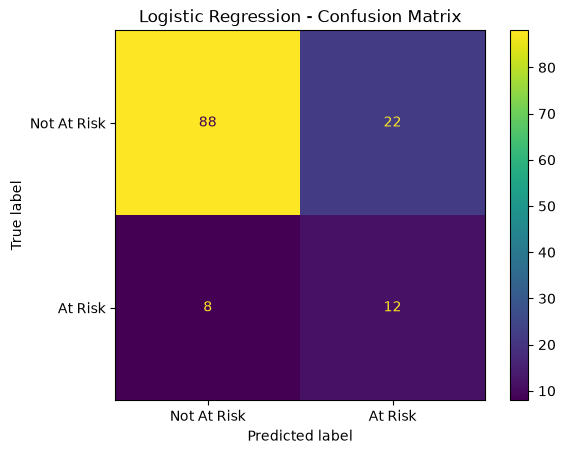

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not At Risk", "At Risk"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [37]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of feature names: 56

First 20 features:
['num__age' 'num__Medu' 'num__Fedu' 'num__traveltime' 'num__studytime'
 'num__failures' 'num__famrel' 'num__freetime' 'num__goout' 'num__Dalc'
 'num__Walc' 'num__health' 'num__absences' 'cat__school_GP'
 'cat__school_MS' 'cat__sex_F' 'cat__sex_M' 'cat__address_R'
 'cat__address_U' 'cat__famsize_GT3']


In [38]:
coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
13,cat__school_GP,-1.122300,1.122300
14,cat__school_MS,1.093347,1.093347
5,num__failures,0.935306,0.935306
51,cat__higher_yes,-0.622765,0.622765
50,cat__higher_no,0.593812,0.593812
37,cat__guardian_father,-0.578165,0.578165
28,cat__Fjob_at_home,-0.576100,0.576100
24,cat__Mjob_health,0.525637,0.525637
38,cat__guardian_mother,0.490846,0.490846
40,cat__schoolsup_no,-0.423849,0.423849


In [39]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train_processed, y_train)

dt_pred = decision_tree.predict(X_test_processed)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [40]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

random_forest.fit(X_train_processed, y_train)

rf_pred = random_forest.predict(X_test_processed)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train_processed, y_train)

gb_pred = gradient_boosting.predict(X_test_processed)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.769231,0.352941,0.60,0.444444
1,Decision Tree,0.700000,0.268293,0.55,0.360656
2,Gradient Boosting,0.830769,0.416667,0.25,0.312500
3,Random Forest,0.807692,0.333333,0.25,0.285714


In [43]:
best_model = results_df.iloc[0]

print("Best model based on F1 Score:")
print(best_model)

Best model based on F1 Score:
Model        Logistic Regression
Accuracy                0.769231
Precision               0.352941
Recall                       0.6
F1 Score                0.444444
Name: 0, dtype: object


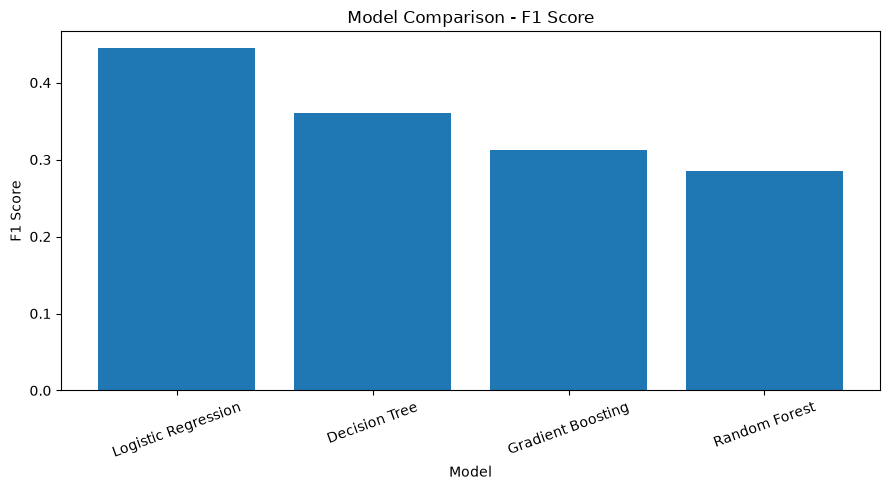

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Model Comparison - F1 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression ROC-AUC:", round(roc_auc, 4))

Logistic Regression ROC-AUC: 0.7759


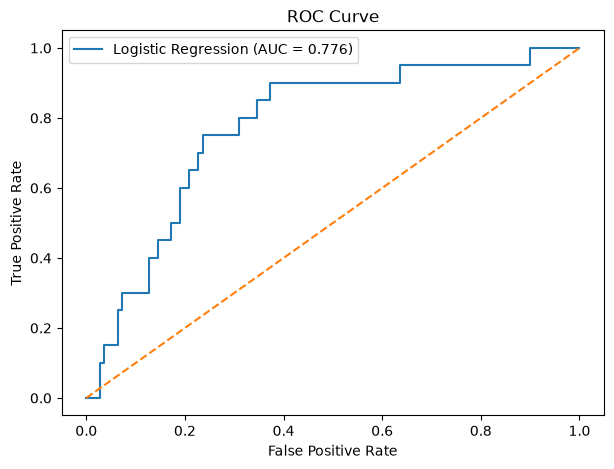

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.326087,0.75,0.454545
1,0.35,0.340909,0.75,0.468750
2,0.40,0.357143,0.75,0.483871
3,0.45,0.342857,0.60,0.436364
4,0.50,0.352941,0.60,0.444444
5,0.55,0.333333,0.50,0.400000
6,0.60,0.346154,0.45,0.391304


In [48]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold_row)

Best threshold based on F1:
Threshold    0.400000
Precision    0.357143
Recall       0.750000
F1 Score     0.483871
Name: 2, dtype: float64


In [49]:
feature_names = preprocessor.get_feature_names_out()

coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print(feature_importance.head(15))

                 Feature  Coefficient  Absolute_Importance
13        cat__school_GP    -1.122300             1.122300
14        cat__school_MS     1.093347             1.093347
5          num__failures     0.935306             0.935306
51       cat__higher_yes    -0.622765             0.622765
50        cat__higher_no     0.593812             0.593812
37  cat__guardian_father    -0.578165             0.578165
28     cat__Fjob_at_home    -0.576100             0.576100
24      cat__Mjob_health     0.525637             0.525637
38  cat__guardian_mother     0.490846             0.490846
40     cat__schoolsup_no    -0.423849             0.423849
12         num__absences     0.396964             0.396964
41    cat__schoolsup_yes     0.394895             0.394895
29      cat__Fjob_health     0.368168             0.368168
47   cat__activities_yes    -0.367793             0.367793
46    cat__activities_no     0.338840             0.338840


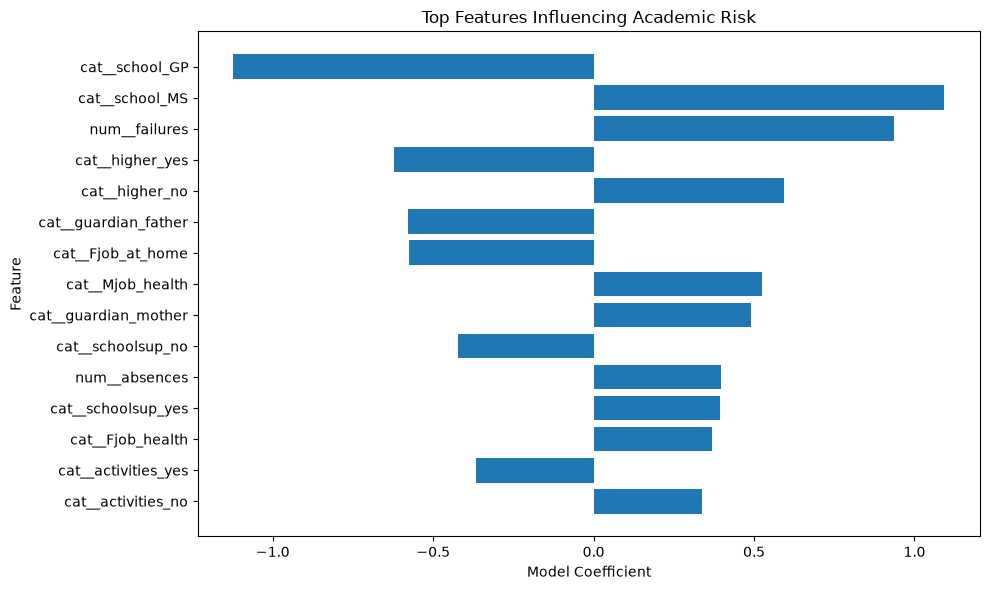

In [50]:
top_features = feature_importance.head(15).sort_values(
    "Absolute_Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Model Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Academic Risk")

plt.tight_layout()
plt.show()

In [54]:
import os

os.makedirs("../results", exist_ok=True)

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

final_pred = logistic_model.predict(X_test_processed)

print("FINAL LOGISTIC REGRESSION EVALUATION")
print("=" * 45)

print(classification_report(
    y_test,
    final_pred,
    target_names=["Not At Risk", "At Risk"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

FINAL LOGISTIC REGRESSION EVALUATION
              precision    recall  f1-score   support

 Not At Risk       0.92      0.80      0.85       110
     At Risk       0.35      0.60      0.44        20

    accuracy                           0.77       130
   macro avg       0.63      0.70      0.65       130
weighted avg       0.83      0.77      0.79       130

Confusion Matrix:
[[88 22]
 [ 8 12]]


<Figure size 700x500 with 0 Axes>

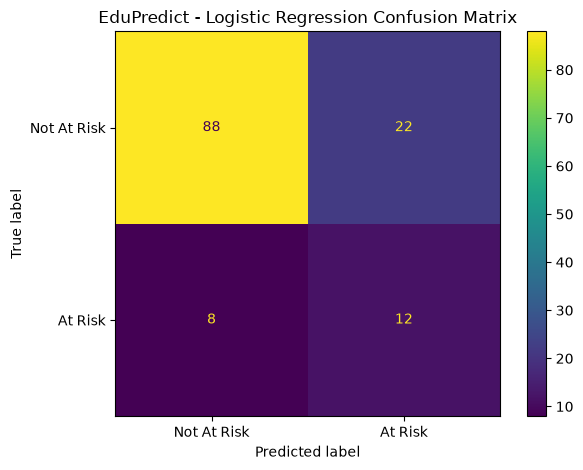

In [55]:
plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["Not At Risk", "At Risk"]
)

plt.title("EduPredict - Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

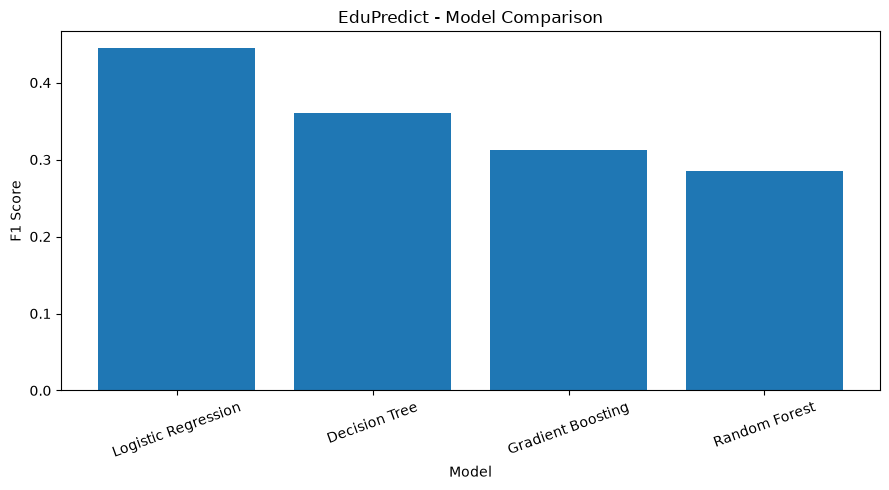

In [56]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("EduPredict - Model Comparison")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../results/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

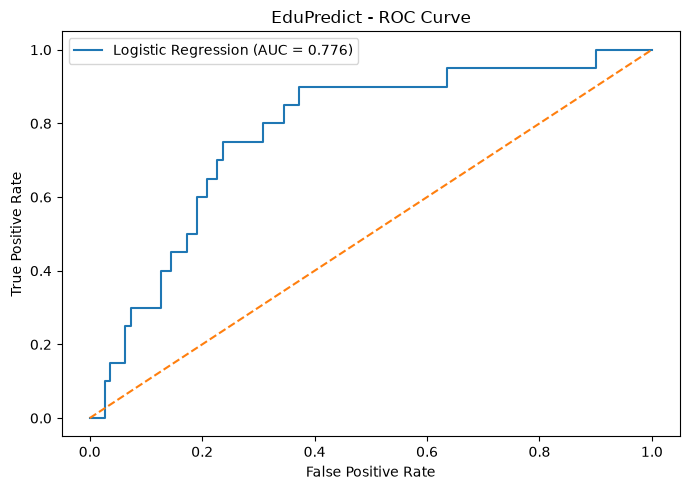

In [57]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EduPredict - ROC Curve")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()